# America Is Finally Paying Attention

Every four years, roughly half the planet stops what it is doing to watch the World Cup. Streets empty. Office productivity collapses. Countries that have never agreed on anything find themselves united behind eleven players and a national crest.

And then there is the United States.

For most of the last two decades, American interest in the World Cup has followed a predictable pattern: near-zero for three years, a brief surge when the tournament actually starts, and then right back to zero. Soccer has always been the sport America was supposed to eventually care about but somehow never quite did.

That might be changing. The 2026 World Cup is being hosted in the United States, Canada, and Mexico, the first time the US has hosted since 1994. And for the first time in the Google Trends era, pre-tournament search interest in the US is sitting at its highest level ever recorded outside of an actual tournament month.

I pulled Google Trends data since 2004 for the search term "World Cup" in the United States and compared it against the tournament timeline to understand what American attention to soccer actually looks like, and whether 2026 is different.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = pd.read_csv('world_cup_trends.csv', skiprows=2)
df.columns = ['date', 'interest']
df['date'] = pd.to_datetime(df['date'])
df['interest'] = pd.to_numeric(df['interest'], errors='coerce')
df = df.dropna()

wc_years = [2006, 2010, 2014, 2018, 2022]
non_wc_avg = df[~df['date'].dt.year.isin(wc_years + [2026])]['interest'].mean()

print(f'Data range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Total months: {len(df)}')
print(f'Average US interest outside tournament years: {non_wc_avg:.1f} / 100')
print(f'All-time peak: {df["interest"].max()} / 100 ({df.loc[df["interest"].idxmax(), "date"].strftime("%B %Y")})')
print(f'Current 2026 average: {df[df["date"].dt.year==2026]["interest"].mean():.1f} / 100')


Data range: 2004-03-01 to 2026-05-01
Total months: 267
Average US interest outside tournament years: 1.7 / 100
All-time peak: 100 / 100 (June 2014)
Current 2026 average: 6.6 / 100


## The Pattern: America Tunes In, Then Immediately Tunes Out

The full 20-year chart tells the story plainly. For most of the year in most years, American Google search interest in "World Cup" hovers between 0 and 2 out of 100. It's essentially invisible.

Then June arrives in a World Cup year and the line spikes. The tournament runs for a month. Americans watch some games, the US men's team either performs surprisingly well or gets knocked out in embarrassing fashion, and by August the interest is back to zero.

It is an extremely predictable pattern. The World Cup exists for Americans as a once every four years novelty rather than a continuous cultural presence. The average non-tournament month over the past 20 years registers just 1.7 out of 100 in search interest.

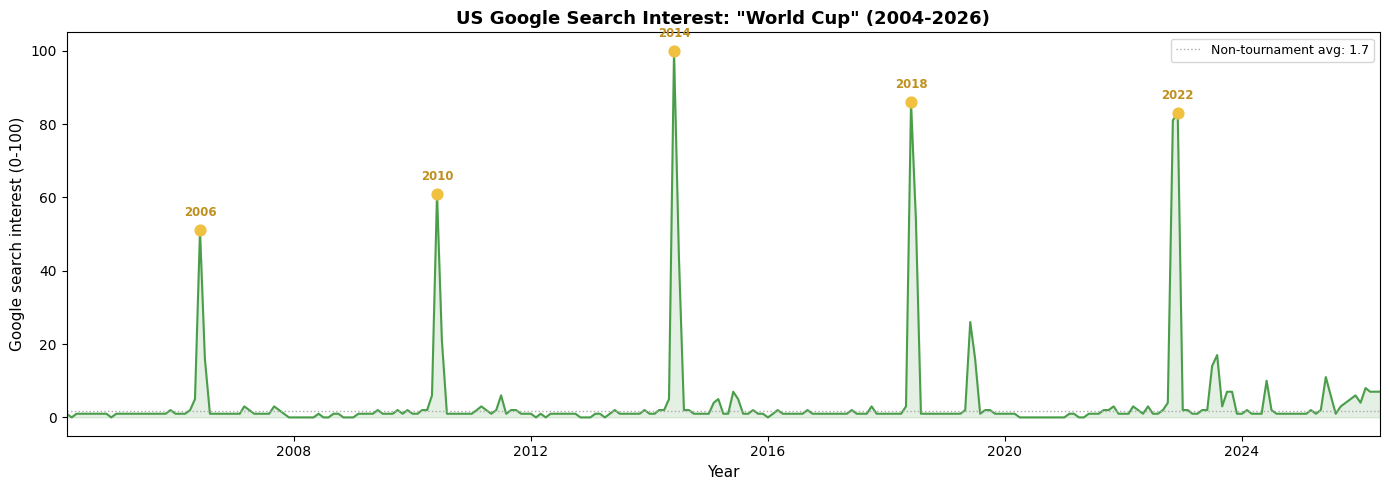

In [26]:
wc_tournament_months = {
    2006: ('2006-06-01', '2006-07-01'),
    2010: ('2010-06-01', '2010-07-01'),
    2014: ('2014-06-01', '2014-07-01'),
    2018: ('2018-06-01', '2018-07-01'),
    2022: ('2022-11-01', '2022-12-01'),
}

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df['date'], df['interest'], alpha=0.15, color='#4a9e4a')
ax.plot(df['date'], df['interest'], color='#4a9e4a', linewidth=1.5)

wc_peaks = {
    2006: (pd.Timestamp('2006-06-01'), 51),
    2010: (pd.Timestamp('2010-06-01'), 61),
    2014: (pd.Timestamp('2014-06-01'), 100),
    2018: (pd.Timestamp('2018-06-01'), 86),
    2022: (pd.Timestamp('2022-12-01'), 83),
}

for yr, (date, val) in wc_peaks.items():
    ax.scatter(date, val, color='#f0c040', s=60, zorder=5)
    ax.annotate(str(yr), xy=(date, val),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=8.5, color='#c09020', fontweight='bold')

ax.axhline(non_wc_avg, color='#aaaaaa', linestyle=':', linewidth=1,
           label=f'Non-tournament avg: {non_wc_avg:.1f}')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Google search interest (0-100)', fontsize=11)
ax.set_title('US Google Search Interest: "World Cup" (2004-2026)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(df['date'].min(), df['date'].max())
plt.tight_layout()
plt.show()


## The Twist: Brazil 2014 Was the Peak, and the US Was Not Even Hosting

Here is the most interesting data point in the entire 20-year dataset.

The all-time high for US search interest in "World Cup" is 100 out of 100, recorded in June 2014. That was the tournament in Brazil, a tournament the United States did not host and exited in the round of 16 after losing to Belgium.

So why did Americans care more about Brazil 2014 than any World Cup before or since?

The timing matters. 2014 was the first World Cup that played out in full view of a mature social media landscape. Twitter and Facebook were ubiquitous. Mobile streaming was very accessible. The US national team also had a legitimate shot at making noise. And the tournament coincided perfectly with summer, when Americans actually have time to watch afternoon games.

Compare that to 2022 in Qatar, which peaked at 83, lower than 2014 despite the US having their best squad in year, a Cinderella run by Morocco, and the most-watched final in history. Qatar's scheduling in November and December, when Americans are distracted by football season and the holidays, likely suppressed what should have been a higher peak.

The chart below shows peak tournament-month interest for each World Cup year.

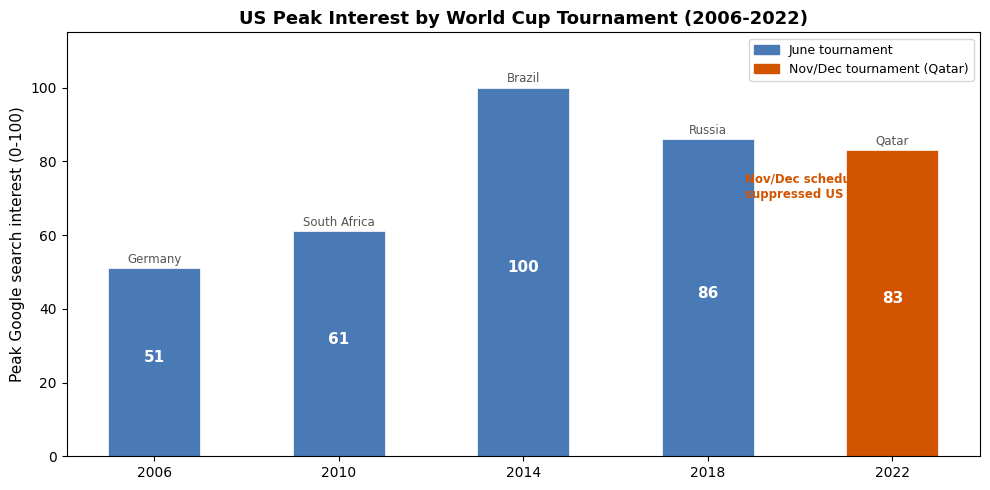

In [27]:
peak_data = {
    'Year': [2006, 2010, 2014, 2018, 2022],
    'Peak Interest': [51, 61, 100, 86, 83],
    'Host': ['Germany', 'South Africa', 'Brazil', 'Russia', 'Qatar'],
    'US Result': ['Group Stage', 'Round of 16', 'Round of 16', 'Did not qualify', 'Round of 16'],
    'Month': ['June', 'June', 'June', 'June', 'November/December']
}
peaks = pd.DataFrame(peak_data)

colors = ['#4a7ab5' if m == 'June' else '#d35400' for m in peaks['Month']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(peaks['Year'].astype(str), peaks['Peak Interest'],
              color=colors, edgecolor='white', linewidth=0.5, width=0.5)

for bar, host, result, val in zip(bars, peaks['Host'], peaks['US Result'], peaks['Peak Interest']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{host}', ha='center', fontsize=8.5, color='#555')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            f'{val}', ha='center', fontsize=11, fontweight='bold', color='white')

ax.annotate('Nov/Dec scheduling\nsuppressed US interest',
            xy=(4, 83), xytext=(3.2, 70),
            fontsize=8.5, color='#d35400', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d35400'))

ax.set_ylabel('Peak Google search interest (0-100)', fontsize=11)
ax.set_title('US Peak Interest by World Cup Tournament (2006-2022)', fontsize=13, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#4a7ab5', label='June tournament'),
    mpatches.Patch(color='#d35400', label='Nov/Dec tournament (Qatar)'),
], fontsize=9)
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()


## 2026: Something Different Is Happening

Now look at where interest sits right now, in May 2026, about a month before the tournament begins.

Since late 2025, US search interest has been ticking upward in a way that has no precedent in this dataset. In the months before every previous World Cup, the pre-tournament baseline was essentially flat. In the three months before Germany 2006, average interest was around 2. Before Brazil 2014, the all-time peak, pre-tournament interest in March and April was still only 3 or 4.

Right now, in the months leading into 2026, interest is sitting between 6 and 8. That is two to three times higher than any equivalent pre-tournament period in the last 20 years.

Some of this is simply proximity. Ticket sales, venue announcements, qualifying drama, and a flood of FIFA marketing have given Americans more reasons to search. But some of it is something harder to measure: the sense that this one actually matters to people who would normally not care.

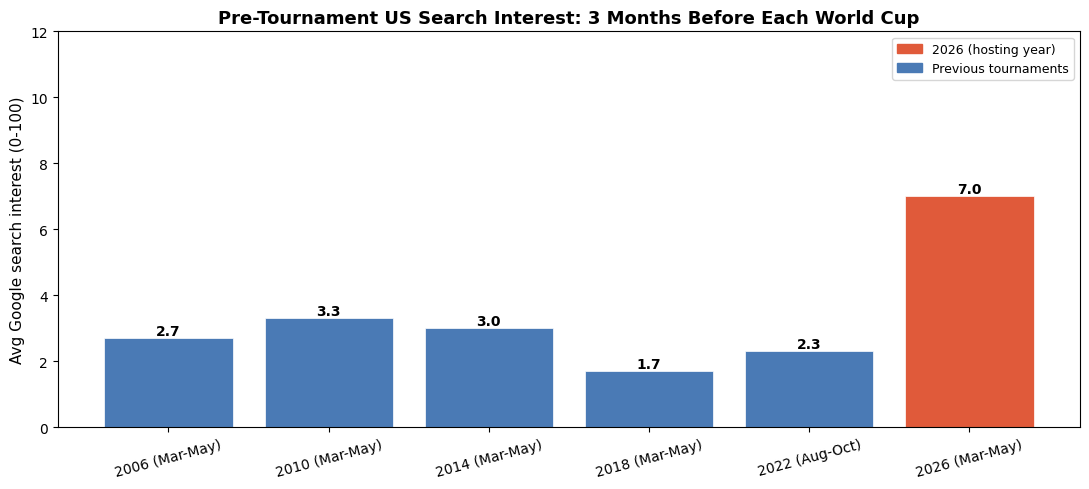

In [28]:
pre_tournament_windows = {
    '2006 (Mar-May)': df[(df['date'] >= '2006-03-01') & (df['date'] <= '2006-05-01')]['interest'].mean(),
    '2010 (Mar-May)': df[(df['date'] >= '2010-03-01') & (df['date'] <= '2010-05-01')]['interest'].mean(),
    '2014 (Mar-May)': df[(df['date'] >= '2014-03-01') & (df['date'] <= '2014-05-01')]['interest'].mean(),
    '2018 (Mar-May)': df[(df['date'] >= '2018-03-01') & (df['date'] <= '2018-05-01')]['interest'].mean(),
    '2022 (Aug-Oct)': df[(df['date'] >= '2022-08-01') & (df['date'] <= '2022-10-01')]['interest'].mean(),
    '2026 (Mar-May)': df[(df['date'] >= '2026-03-01') & (df['date'] <= '2026-05-01')]['interest'].mean(),
}

pre_df = pd.DataFrame(list(pre_tournament_windows.items()), columns=['Window', 'Avg Interest'])

bar_colors = ['#e05a3a' if '2026' in w else '#4a7ab5' for w in pre_df['Window']]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(pre_df['Window'], pre_df['Avg Interest'].round(1),
              color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, pre_df['Avg Interest']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Avg Google search interest (0-100)', fontsize=11)
ax.set_title('Pre-Tournament US Search Interest: 3 Months Before Each World Cup',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.legend(handles=[
    mpatches.Patch(color='#e05a3a', label='2026 (hosting year)'),
    mpatches.Patch(color='#4a7ab5', label='Previous tournaments'),
], fontsize=9)
ax.set_ylim(0, 12)
plt.tight_layout()
plt.show()


## Conclusion

Twenty years of Google Trends data tells a clear story about the United States and the World Cup: Americans have always cared, but only barely, and only when the games are actually on.

The non-tournament average of 1.7 out of 100 is not just low, it reflects a country where soccer has genuinely struggled to compete with football, basketball, and baseball for cultural attention outside of a one-month window every four years. Even the all-time peak, Brazil 2014's 100 out of 100, dropped back to essentially zero within two months of the final.

But the 2026 data is different. Pre-tournament interest is running two to three times higher than any equivalent period before a previous World Cup. Some of that is the hosting effect, with billions of dollars in infrastructure spending, constant news coverage, and the simple fact that the games are being played in American cities. Some of it is the US men's team, which will hopefully be competitive once again at this tournament on home soil. And some of it may be something more durable: the slow process of soccer actually embedding itself in American culture finally starting to show up in the data.

Whether the post-tournament line drops back to 2 or stays higher this time is the real question. The Google Trends chart cannot answer that yet. But for the first time in 20 years of data, the pre-tournament baseline suggests that the answer might not be what it has always been.